In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install albumentations
!pip install timm
!pip install --upgrade opencv-contrib-python

In [3]:
import re
import os

pattern = r"(\d+)\.jpg$"
img_numbers=[]

for dirname, _, filenames in os.walk('/content/drive/MyDrive/Colab/Pothole_detection_CV_Project/data/annotated-images'):
    for filename in filenames:
        match = re.search(pattern,filename,re.IGNORECASE)

        if match:
            number = match.group(1)
            img_numbers.append(number)

img_numbers.sort()

In [17]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import cv2
import random

import os
import random
import time
from pathlib import Path
from typing import Tuple, Dict, Any, List

import torch
import torch.utils.data
from torch.utils.data import Dataset, DataLoader
from torchvision.ops import box_convert
import torchvision
from torchvision.transforms import functional as TF

from PIL import Image
from xml.dom import minidom
import csv
import torch
from tqdm.notebook import tqdm
import pandas as pd
from sklearn.preprocessing import LabelEncoder

In [5]:
img_numbers

['1',
 '10',
 '100',
 '101',
 '102',
 '103',
 '104',
 '105',
 '106',
 '107',
 '108',
 '109',
 '11',
 '110',
 '111',
 '112',
 '113',
 '114',
 '115',
 '116',
 '117',
 '118',
 '119',
 '12',
 '120',
 '121',
 '122',
 '123',
 '124',
 '125',
 '126',
 '127',
 '128',
 '129',
 '13',
 '130',
 '131',
 '132',
 '133',
 '134',
 '135',
 '136',
 '137',
 '138',
 '139',
 '14',
 '140',
 '141',
 '142',
 '143',
 '144',
 '145',
 '146',
 '147',
 '148',
 '149',
 '15',
 '150',
 '151',
 '152',
 '153',
 '154',
 '155',
 '156',
 '157',
 '158',
 '159',
 '16',
 '160',
 '161',
 '162',
 '163',
 '164',
 '165',
 '166',
 '167',
 '168',
 '169',
 '17',
 '170',
 '171',
 '172',
 '173',
 '174',
 '175',
 '176',
 '177',
 '178',
 '179',
 '18',
 '180',
 '181',
 '182',
 '183',
 '184',
 '185',
 '186',
 '187',
 '188',
 '189',
 '19',
 '190',
 '191',
 '192',
 '193',
 '194',
 '195',
 '196',
 '197',
 '198',
 '199',
 '2',
 '20',
 '200',
 '201',
 '202',
 '203',
 '204',
 '205',
 '206',
 '207',
 '208',
 '209',
 '21',
 '210',
 '211',
 '212',


In [6]:
import os
import pandas as pd
import cv2
from xml.dom import minidom

def extract_multiple_bboxes(xml_path, image_path, base_dir):
    """
    Parses an XML file and returns a list of bounding boxes and image metadata.

    Parameters:
        xml_path (str): Full path to the XML annotation file
        image_path (str): Path to the image file
        base_dir (str): Base directory where the image files are stored

    Returns:
        image_full_path (str): Full path to the image
        width (int): Width of the image
        height (int): Height of the image
        boxes (list of tuples): List of bounding boxes (x1, y1, x2, y2)
    """
    # Parse the XML annotation file
    xml_doc = minidom.parse(xml_path)

    # Read image to get dimensions
    height, width = cv2.imread(image_path).shape[:2]

    # Extract filename and construct full image path
    filename_tag = xml_doc.getElementsByTagName('filename')[0]
    filename = filename_tag.firstChild.data
    image_full_path = os.path.join(base_dir, filename)

    # Extract all bounding boxes from <object> tags
    objects = xml_doc.getElementsByTagName('object')
    boxes = []

    for obj in objects:
        xmin = int(obj.getElementsByTagName('xmin')[0].firstChild.data)
        ymin = int(obj.getElementsByTagName('ymin')[0].firstChild.data)
        xmax = int(obj.getElementsByTagName('xmax')[0].firstChild.data)
        ymax = int(obj.getElementsByTagName('ymax')[0].firstChild.data)

        boxes.append((xmin, ymin, xmax, ymax))

    return image_full_path, width, height, boxes


### Dataset

In [7]:
import pandas as pd

# Function to convert XML files to CSV
def xml_to_csv(data_dir):
    xml_list={'filename':[],
              'width':[],
              'height':[],
              'xmin':[],
              'ymin':[],
              'xmax':[],
              'ymax':[]
              }

  # Loop over each of the image and its label
    for i in img_numbers:

        mat = f"img-{i}.xml"
        image_file = f"img-{i}.jpg"

      # Full mat path
        mat_path = os.path.join(data_dir, mat)

      # Full path Image
        img_path = os.path.join(data_dir, image_file)

      # Get Attributes for each image
        filename, width, height, bbox = extract_multiple_bboxes(mat_path, img_path,data_dir)
        iter=1
        for xmin,	ymin,	xmax,	ymax in bbox:
          name=number = re.search(r'img-(\d+)\.jpg', filename).group(1)
          if iter<10:
            xml_list['filename'].append(str(f'{name}-00{iter}'))
          else:
            xml_list['filename'].append(str(f'{name}-0{iter}'))
          xml_list['width'].append(width)
          xml_list['height'].append(height)
          xml_list['xmin'].append(xmin)
          xml_list['ymin'].append(ymin)
          xml_list['xmax'].append(xmax)
          xml_list['ymax'].append(ymax)
          iter+=1

  # Create the DataFrame from mat_list
    xml_df = pd.DataFrame(xml_list)

  # Return the dataframe
    return xml_df

# Run the function to convert all the xml files to a Pandas DataFrame
labels_df = xml_to_csv(data_dir="/content/drive/MyDrive/Colab/Pothole_detection_CV_Project/data/annotated-images")

# Saving the Pandas DataFrame as CSV File
labels_df.to_csv(('dataset.csv'), index=None)

In [ ]:
labels_df

In [8]:
DATA_DIR = "/content/drive/MyDrive/Colab/Pothole_detection_CV_Project/data/annotated-images"

In [15]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CSV_PATH = "/content/dataset.csv"
IMG_SIZE_LIMIT = 1333          # max shorter/longer side resizes handled by model; we will only do light aug
BATCH_SIZE = 4
NUM_WORKERS = 2
NUM_EPOCHS = 20
LR = 0.0005
WARMUP_ITERS = 500
OUT_DIR = "outputs"            # will hold checkpoints
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
PCT_STEP = 5  # print every 10% (set to 1, 5, etc. if you want finer updates)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

BATCH_SIZE = 16
IMG_SIZE = 128
LR = 0.01
EPOCHS = 2
MODEL_NAME = "res2net50d.in1k"
NUM_COR = 4

In [12]:
def check_image(img_no):
  rectangles = []
  i=1
  # Construct the filename in the format found in labels_df (e.g., '8-001', '10-001')
  if img_no < 10:
      filename = f'{img_no}-00{i}'
  else:
      filename = f'{img_no}-0{i}'

  # Check if the constructed filename exists in the DataFrame
  if filename not in labels_df['filename'].values:
      print(f"Filename {filename} not found in labels_df.")
      return  # Exit the function if the file is not found

  ind = int(labels_df.index[labels_df['filename'] == filename][0])

  while True:
    if img_no < 10:
        filename = f'{img_no}-00{i}'
    else:
        filename = f'{img_no}-0{i}'

    if filename not in labels_df['filename'].values:
      break

    ind = labels_df.index[labels_df['filename'] == filename][0]
    row = labels_df.iloc[ind]
    img = cv2.imread(f'{DATA_DIR}/img-{img_no}.jpg')
    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    pt1 = (row.xmin, row.ymin)
    pt2 = (row.xmax, row.ymax)

    rectangles.append((pt1,pt2))
    i+=1
    ind+=1

  for rect in rectangles:
    pt1, pt2 = rect
    cv2.rectangle(img, pt1, pt2, (255,0,0),2)
    plt.imshow(img)

In [10]:
img_1=8 #input a number of your choice
img_2=102 #input a number of your choice

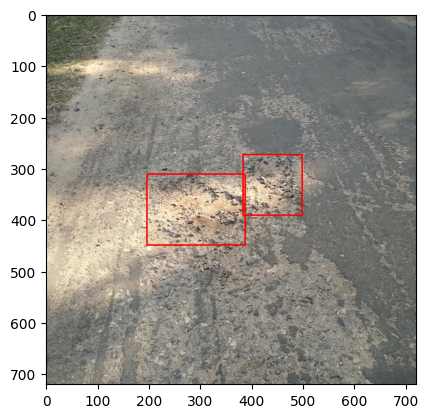

In [13]:
check_image(img_1)

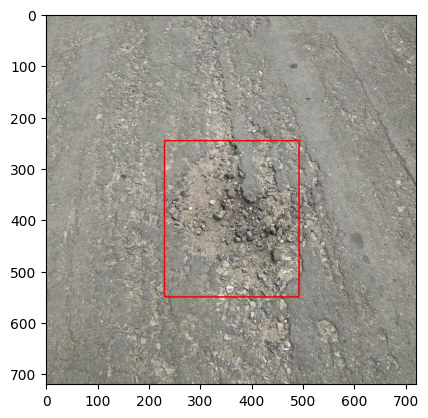

In [ ]:
check_image(img_2)

In [27]:
import re
in_csv  = CSV_PATH
out_csv = "updated_dataset.csv"


base_dir = "/content/drive/MyDrive/Colab/Pothole_detection_CV_Project/data/annotated-images"

df = pd.read_csv(in_csv)

# extract the leading number before the first '-' in the filename
def to_img_name(fname: str) -> str:
    m = re.match(r"(\d+)", str(fname))
    n = m.group(1) if m else str(fname)
    return f"img-{n}.jpg"

df["image_path"] = df["filename"].apply(lambda x: str(Path(base_dir) / to_img_name(x)))
df["label"] = "pothole"

# optional: reorder columns to match your screenshot
cols = ["filename", "width", "height", "xmin", "ymin", "xmax", "ymax", "image_path", "label"]
df = df[cols]

CSV_PATH=out_csv
df.to_csv(out_csv, index=False)
print(f"Saved → {out_csv}")

Saved → updated_dataset.csv


In [18]:
# Dataset
# -----------------------
class PotholeCSV(Dataset):
    """
    Expects a CSV with columns:
    image_path,xmin,ymin,xmax,ymax,label
    Multiple rows per image allowed (one per box). Label must be 'pothole'.
    """
    def __init__(self, csv_file: str, train: bool = True):
        self.df = pd.read_csv(csv_file)
        # Ensure trimmed paths/labels
        self.df["image_path"] = self.df["image_path"].astype(str).str.strip()
        self.df["label"] = self.df["label"].astype(str).str.strip().str.lower()
        # Group rows by image
        self.img_to_rows = self.df.groupby("image_path")
        self.image_paths = list(self.img_to_rows.groups.keys())
        self.train = train

    def __len__(self):
        return len(self.image_paths)

    def _random_hflip(self, img, boxes, p=0.5):
        if random.random() < p:
            img = TF.hflip(img)
            w = img.shape[2]
            # boxes: [N,4] in [xmin,ymin,xmax,ymax]
            boxes = boxes.clone()
            xmin = boxes[:, 0].clone()
            xmax = boxes[:, 2].clone()
            boxes[:, 0] = w - xmax
            boxes[:, 2] = w - xmin
        return img, boxes

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, Dict[str, Any], str]:
        img_path = self.image_paths[idx]
        rows = self.img_to_rows.get_group(img_path)

        # Load with cv2 BGR -> RGB
        img_bgr = cv2.imread(img_path)
        if img_bgr is None:
            raise FileNotFoundError(f"Could not read image: {img_path}")
        img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        # To tensor (C,H,W)
        img_t = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0

        # Boxes
        bxs = rows[["xmin", "ymin", "xmax", "ymax"]].values.astype(np.float32)
        boxes = torch.as_tensor(bxs, dtype=torch.float32)

        # Clip to image bounds (defensive)
        _, h, w = img_t.shape
        boxes[:, [0, 2]] = boxes[:, [0, 2]].clamp(0, w - 1)
        boxes[:, [1, 3]] = boxes[:, [1, 3]].clamp(0, h - 1)

        # Remove degenerate boxes, if any
        keep = (boxes[:, 2] > boxes[:, 0]) & (boxes[:, 3] > boxes[:, 1])
        boxes = boxes[keep]

        # Labels (single class: pothole -> 1)
        labels = torch.ones((boxes.shape[0],), dtype=torch.int64)

        # Optional light aug for train
        if self.train:
            img_t, boxes = self._random_hflip(img_t, boxes, p=0.5)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx]),
        }

        return img_t, target, img_path




In [19]:
def collate_fn(batch):
    imgs, targs, paths = list(zip(*batch))
    return list(imgs), list(targs), list(paths)

In [20]:
# Model
# -----------------------
def build_model(num_classes: int = 2):
    """
    num_classes includes background. For single 'pothole' class: 2 (background + pothole).
    """
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn_v2(
        weights="DEFAULT",
        trainable_backbone_layers=3,
    )
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
        in_features, num_classes
    )
    return model

In [21]:
# Utils
# -----------------------
def split_train_valid(csv_path: str, valid_frac: float = 0.2):
    df = pd.read_csv(csv_path)
    # Shuffle by image, not by row
    groups = df.groupby("image_path").size().reset_index(name="n")
    paths = groups["image_path"].tolist()
    random.shuffle(paths)
    v = int(len(paths) * valid_frac)
    valid_paths = set(paths[:v])
    train_df = df[~df["image_path"].isin(valid_paths)].copy()
    valid_df = df[df["image_path"].isin(valid_paths)].copy()

    tmp_dir = Path(OUT_DIR)
    tmp_dir.mkdir(parents=True, exist_ok=True)
    train_csv = str(tmp_dir / "train_split.csv")
    valid_csv = str(tmp_dir / "valid_split.csv")
    train_df.to_csv(train_csv, index=False)
    valid_df.to_csv(valid_csv, index=False)
    return train_csv, valid_csv

In [22]:
def warmup_lr_factor(iter_idx, warmup_iters):
    if iter_idx >= warmup_iters:
        return 1.0
    alpha = float(iter_idx) / float(warmup_iters)
    return 0.001 + (1.0 - 0.001) * alpha  # start tiny, grow to 1.0

In [23]:
# Train & Eval
# -----------------------
def train_one_epoch(
    model, optimizer, loader, epoch_idx: int, total_epochs: int, scaler=None
):
    model.train()
    loss_avg = 0.0
    n = 0
    start = time.time()

    total_batches = len(loader)
    next_pct = PCT_STEP  # first milestone to print (e.g., 10%)

    for i, (images, targets, _) in enumerate(loader):
        images = [img.to(DEVICE) for img in images]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        # warmup for epoch 0
        if epoch_idx == 0:
            for pg in optimizer.param_groups:
                base_lr = pg.get("initial_lr", pg["lr"])
                pg["lr"] = base_lr * warmup_lr_factor(i, WARMUP_ITERS)

        optimizer.zero_grad(set_to_none=True)

        if scaler is not None:
            with torch.cuda.amp.autocast():
                losses = model(images, targets)
                loss = sum(l for l in losses.values())
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            losses = model(images, targets)
            loss = sum(l for l in losses.values())
            loss.backward()
            optimizer.step()

        n += 1
        loss_avg += loss.item()

        # ---- percentage progress print ----
        processed = i + 1
        pct = int(processed * 100 / max(1, total_batches))
        if pct >= next_pct or processed == total_batches:
            # print once per milestone
            print(
                f"  [epoch {epoch_idx+1}/{total_epochs}] "
                f"{pct:3d}%  ({processed}/{total_batches})  "
                f"batch_loss: {loss.item():.4f}"
            )
            # advance to the next milestone
            while next_pct <= pct:
                next_pct += PCT_STEP
        # -----------------------------------

    elapsed = time.time() - start
    return loss_avg / max(1, n), elapsed

In [24]:
@torch.no_grad()
def eval_loss(model, loader):
    model.eval()
    losses_total = 0.0
    n = 0
    for images, targets, _ in loader:
        images = [img.to(DEVICE) for img in images]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
        # Detection models return a loss dict in train mode only.
        # For a rough validation *loss*, temporarily switch to train() without grads.
        was_training = model.training
        model.train()
        losses = model(images, targets)
        model.eval()
        loss = sum(l for l in losses.values()).item()
        losses_total += loss
        n += 1
    return losses_total / max(1, n)

In [25]:
# Visualization (inference)
# -----------------------
@torch.no_grad()
def predict_on_image(model, img_path: str, score_thresh: float = 0.5, show: bool = True):
    bgr = cv2.imread(img_path)
    if bgr is None:
        raise FileNotFoundError(img_path)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    t = torch.from_numpy(rgb).permute(2, 0, 1).float() / 255.0
    pred = model([t.to(DEVICE)])[0]
    boxes = pred["boxes"].detach().cpu().numpy()
    scores = pred["scores"].detach().cpu().numpy()
    # draw
    vis = rgb.copy()
    for bb, sc in zip(boxes, scores):
        if sc < score_thresh:
            continue
        x1, y1, x2, y2 = bb.astype(int)
        cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(
            vis, f"pothole {sc:.2f}", (x1, max(0, y1 - 6)),
            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2
        )
    if show:
        plt.figure(figsize=(10, 8))
        plt.imshow(vis)
        plt.axis("off")
        plt.title(Path(img_path).name)
        plt.show()
    return pred

In [ ]:
os.makedirs(OUT_DIR, exist_ok=True)
train_csv, valid_csv = split_train_valid(CSV_PATH, valid_frac=0.2)

In [ ]:
ds_train = PotholeCSV(train_csv, train=True)
ds_valid = PotholeCSV(valid_csv, train=False)

In [ ]:
loader_train = DataLoader(
     ds_train, batch_size=BATCH_SIZE, shuffle=True,
     num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True
 )
loader_valid = DataLoader(
     ds_valid, batch_size=BATCH_SIZE, shuffle=False,
     num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True
 )

In [ ]:
model = build_model(num_classes=2).to(DEVICE)

In [ ]:
 # Optimizer
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=LR, momentum=0.9, weight_decay=1e-4)
for pg in optimizer.param_groups:
    pg["initial_lr"] = LR

In [ ]:
lr_sched = torch.optim.lr_scheduler.StepLR(optimizer, step_size=8, gamma=0.1)
scaler = torch.cuda.amp.GradScaler() if DEVICE == "cuda" else None

In [ ]:
best_val = float("inf")
best_path = os.path.join(OUT_DIR, "fasterrcnn_potholes_best.pth")

In [ ]:
print(f"Device: {DEVICE}")
print(f"Train images: {len(ds_train)} | Valid images: {len(ds_valid)}")

In [ ]:
for epoch in range(NUM_EPOCHS):
  tr_loss, tr_time = train_one_epoch(model, optimizer, loader_train, epoch, NUM_EPOCHS, scaler=scaler)
  val_loss = eval_loss(model, loader_valid)
  lr_sched.step()

  print(
         f"Epoch {epoch+1}/{NUM_EPOCHS} — "
         f"train_loss: {tr_loss:.4f} ({tr_time:.1f}s) | "
            f"valid_loss: {val_loss:.4f} | lr: {optimizer.param_groups[0]['lr']:.6f}"
  )

  if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), best_path)
        print(f"  ↳ New best model saved to {best_path} (val_loss {best_val:.4f})")

In [ ]:
# Save final model too
final_path = os.path.join(OUT_DIR, "fasterrcnn_potholes_final.pth")
torch.save(model.state_dict(), final_path)
print(f"Training complete. Final weights: {final_path}")

In [ ]:
# Quick sanity check on a few validation images
model.eval()
sample_paths = ds_valid.image_paths[:3]
for p in sample_paths:
    predict_on_image(model, p, score_thresh=0.5, show=True)